# Notebook 2: Data Cleaning via RBF Reconstruction

## Objective
Implement the 'One-Shot' Radial Basis Function (RBF) reconstruction strategy to restore the spatial grid by correcting non-physical negative values in all affected parameters while preserving the underlying spatial correlation structure.

**Methodology:**
1. Drop low-information columns (Remarks)
2. Mask negative values as NaN (identify invalid measurements)
3. Train RBF interpolator on valid (non-negative) data points
4. Predict values across the entire spatial domain
5. Validate reconstruction against original trends

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import Rbf
import warnings
warnings.filterwarnings('ignore')

# Set visualization parameters
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


## Data Loading and Preprocessing

**Description:** Load the raw dataset and remove the Remarks column.

In [2]:
# Load the dataset
df_raw = pd.read_csv('../data/china_water_pollution_data.csv')

# Drop Remarks column (low information value)
df_clean = df_raw.drop(columns=['Remarks'])
df_original = df_clean.copy()

print(f"Dataset loaded. Shape: {df_clean.shape}")

Dataset loaded. Shape: (3000, 24)


## The Reconstruction Engine: RBF Interpolation Setup

**Description:** Mask negative values as NaN and prepare the RBF interpolation framework.

In [3]:
import numpy as np
import pandas as pd
from scipy.interpolate import Rbf
from sklearn.preprocessing import MinMaxScaler

# 1. DEFINE THE FUNCTION
def rbf_reconstruct(coords, values, function='multiquadric', smooth=0.1, epsilon=None):
    valid_mask = ~np.isnan(values)
    valid_coords = coords[valid_mask]
    valid_values = values[valid_mask]
    
    # Edge-Case Guard: Density Check
    if len(valid_values) < 10:
        return np.full(len(values), np.nanmean(valid_values) if len(valid_values) > 0 else 0)
    
    # Create RBF interpolator
    # Note: coords are already scaled before being passed to this function
    if epsilon is not None:
        rbf = Rbf(valid_coords[:, 0], valid_coords[:, 1], valid_values, 
                  function=function, smooth=smooth, epsilon=epsilon)
    else:
        rbf = Rbf(valid_coords[:, 0], valid_coords[:, 1], valid_values, 
                  function=function, smooth=smooth)
    
    # Predict and enforce non-negativity (Physical Constraint)
    reconstructed = rbf(coords[:, 0], coords[:, 1])
    return np.maximum(reconstructed, 0)

# 2. SETUP PARAMETERS
smoothing_map = {
    'Heavy_Metals_Hg_ug_L': 0.001, 
    'Heavy_Metals_Pb_ug_L': 0.001,
    'Heavy_Metals_Cd_ug_L': 0.001,
    'Ammonia_N_mg_L': 0.1,
    'Total_Phosphorus_mg_L': 0.1,
    'Nitrite_mg_L': 0.1
}

epsilon_map = {
    'Heavy_Metals_Hg_ug_L': 0.5, 
    'Heavy_Metals_Pb_ug_L': 0.5,
    'Heavy_Metals_Cd_ug_L': 0.5,
    'Ammonia_N_mg_L': 2.0,
    'Total_Phosphorus_mg_L': 2.0,
    'Nitrite_mg_L': 2.0
}

negative_value_cols = list(smoothing_map.keys())

# 3. GLOBAL SCALING (Crucial for Master's Level Accuracy)
scaler = MinMaxScaler()
coords_raw = df_clean[['Longitude', 'Latitude']].values
coords_scaled = scaler.fit_transform(coords_raw)

# 4. EXECUTION LOOP
print("Starting RBF Spatial Reconstruction...")

for col in negative_value_cols:
    print(f"Reconstructing {col}...")
    
    # Pre-clean: Replace negatives with NaN so the RBF ignores them during training
    df_clean.loc[df_clean[col] < 0, col] = np.nan
    
    original_series = df_clean[col].values
    smooth_val = smoothing_map.get(col, 0.1)
    epsilon_val = epsilon_map.get(col, None)
    
    # Call the defined function using scaled coordinates
    df_clean[col] = rbf_reconstruct(coords_scaled, original_series, 
                                   smooth=smooth_val, epsilon=epsilon_val)

print("Reconstruction Complete. All surfaces synchronized.")

Starting RBF Spatial Reconstruction...
Reconstructing Heavy_Metals_Hg_ug_L...
Reconstructing Heavy_Metals_Pb_ug_L...
Reconstructing Heavy_Metals_Cd_ug_L...
Reconstructing Ammonia_N_mg_L...
Reconstructing Total_Phosphorus_mg_L...
Reconstructing Nitrite_mg_L...
Reconstruction Complete. All surfaces synchronized.


## Execute RBF Reconstruction

**Description:** Apply RBF to each affected column.

In [4]:
# 1. Scale once, globally, to keep all chemicals aligned on the same grid
scaler = MinMaxScaler()
coords_raw = df_clean[['Longitude', 'Latitude']].values
coords_scaled = scaler.fit_transform(coords_raw) 

print("Starting RBF Spatial Reconstruction...")

for col in negative_value_cols:
    print(f"-> Processing {col}...")
    
    # Get current values (including the NaNs we want to fill)
    original_series = df_clean[col].values
    
    # Retrieve hyperparameters from your maps
    smooth_val = smoothing_map.get(col, 0.1)
    epsilon_val = epsilon_map.get(col, None)
    
    # CRITICAL: Pass 'coords_scaled' instead of 'coords'
    # This ensures Latitude 32.5 always equals the same 0-1 value for every chemical
    df_clean[col] = rbf_reconstruct(
        coords_scaled, 
        original_series, 
        smooth=smooth_val, 
        epsilon=epsilon_val
    )

print("Reconstruction Complete. Spatial surfaces synthesized.")

Starting RBF Spatial Reconstruction...
-> Processing Heavy_Metals_Hg_ug_L...
-> Processing Heavy_Metals_Pb_ug_L...
-> Processing Heavy_Metals_Cd_ug_L...
-> Processing Ammonia_N_mg_L...
-> Processing Total_Phosphorus_mg_L...
-> Processing Nitrite_mg_L...
Reconstruction Complete. Spatial surfaces synthesized.


## RBF Model Error Metrics

**Description:** To validate the RBF model's performance, we perform an 80-20 train-test split on the valid (non-negative) data points of a representative column (e.g., `Heavy_Metals_Hg_ug_L`). We train the RBF model on the 80% training set and calculate the Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) on the 20% validation set.

Global Validation Loop over all features:

Heavy_Metals_Hg_ug_L      - RMSE: 0.0479 | MAE: 0.0393
Heavy_Metals_Pb_ug_L      - RMSE: 2.0459 | MAE: 1.6134
Heavy_Metals_Cd_ug_L      - RMSE: 0.1924 | MAE: 0.1539
Ammonia_N_mg_L            - RMSE: 0.1928 | MAE: 0.1558
Total_Phosphorus_mg_L     - RMSE: 0.0497 | MAE: 0.0408
Nitrite_mg_L              - RMSE: 0.0093 | MAE: 0.0075


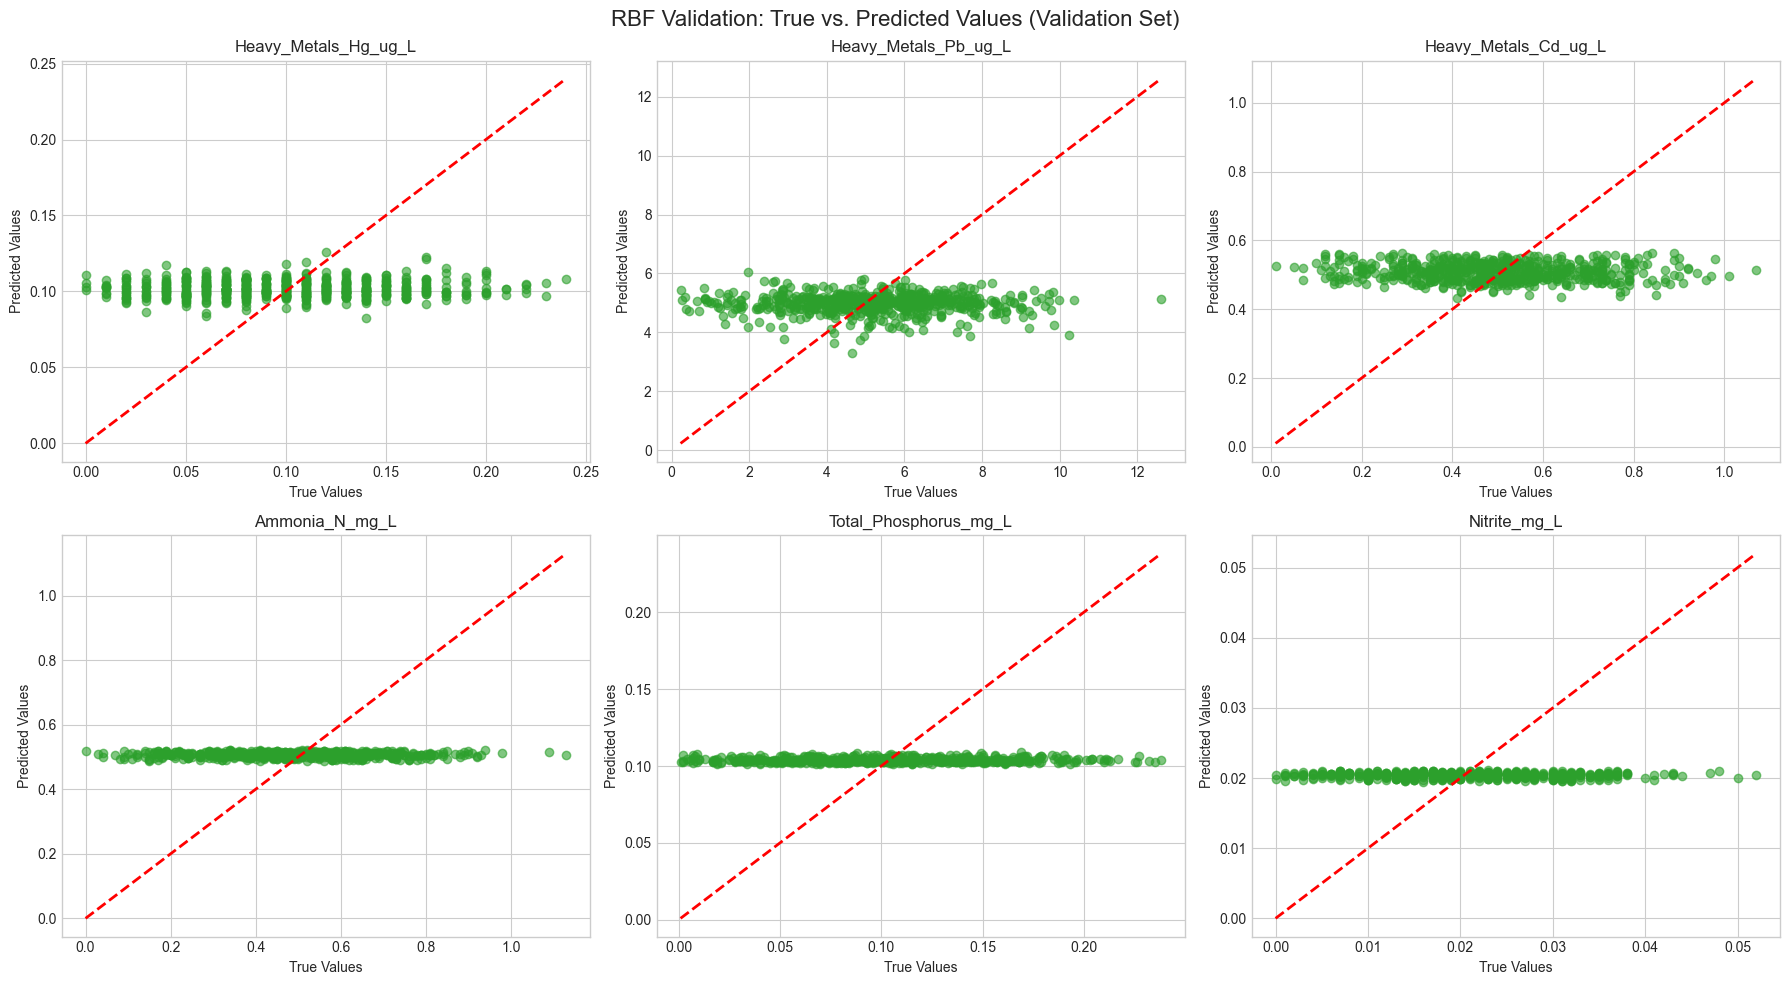

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

print("Global Validation Loop over all features:\n")

coords = df_original[['Longitude', 'Latitude']].values

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(negative_value_cols):
    original_series = df_original[col].values
    
    # Only use valid (non-negative) points
    valid_mask = original_series >= 0
    valid_coords = coords[valid_mask]
    valid_values = original_series[valid_mask]
    
    # Edge-case skip
    if len(valid_values) < 10:
        print(f"{col:25} - Skipping validation (insufficient points)")
        continue
    
    # Shuffle Split 80/20
    X_train, X_test, y_train, y_test = train_test_split(valid_coords, valid_values, test_size=0.2, random_state=42)
    
    # Coordinate Scaling
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train RBF
    smooth_val = smoothing_map.get(col, 0.1)
    epsilon_val = epsilon_map.get(col, None)
    
    rbf_val = Rbf(X_train_scaled[:, 0], X_train_scaled[:, 1], y_train, 
                  function='multiquadric', smooth=smooth_val, epsilon=epsilon_val)
    
    # Predict
    y_pred = rbf_val(X_test_scaled[:, 0], X_test_scaled[:, 1])
    y_pred = np.maximum(y_pred, 0)
    
    # Errors
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{col:25} - RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    
    # Visualize
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, color='#2ca02c')
    
    # Plot y=x line
    min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')

plt.suptitle('RBF Validation: True vs. Predicted Values (Validation Set)', fontsize=16)
plt.tight_layout()
plt.show()


## Validation and Visualization

**Description:** Compare histograms and save the cleaned dataset.

In [6]:
# Quick check for remaining negatives
neg_check = (df_clean[negative_value_cols] < 0).sum().sum()
print(f"Total negative values remaining: {neg_check}")

# Save output
df_clean.to_csv('../output/cleaned_water_pollution_data.csv', index=False)
print("Cleaned dataset saved successfully.")

Total negative values remaining: 0
Cleaned dataset saved successfully.
